# T4 — Final model: training, historical performance and live recommendation

This is the **final, operational notebook**. It:
1. **Trains** the chosen models on all usable history. The choices were made in T1 (gas), T2 (secondary air) and T3 (barrier boost).
2. **Proves on history** how the approach would have performed: walk-forward on Jun–Aug 2026 and on the unseen month Sep 2026, per 5-t draw band, and draw-adjusted.
3. Checks that **every recommended value stays inside the historical limits** (P1–P99).
4. Gives **recommended ranges** (NG by NCV and draw; boost by MB3).
5. Has an **input cell** (§5): type the current plant values and get the recommendation.
6. Has a **back-test cell** (§6): for the same input values, find similar days in history and show their average SFC, and what the recommender would have achieved on those days.

| Recommender | Method | Inputs | Output |
|---|---|---|---|
| Gas | OLS on all past usable days: gas heat ~ draw + barrier + melter boost + furnace age, shifted to the 25th percentile of the last 45 days' errors | NCV (latest), draw, barrier + melter boost (last hour, from DB); optical (last 24 h) as a **guard-rail** only | NG setpoint every 15 min (= daily heat ÷ 96 ÷ NCV) |
| Secondary air | air per Mcal × heat (target = P25 of last 45 days, floor = historical P5) | same | secondary air, AFR = air ÷ NG |
| Barrier boost | integral controller on MB3: bb(t) = bb(t−1) + 0.1 × (target − MB3) ÷ gain | MB3 now, boost last hour (melter boost not needed, T3 §4) | barrier boost for the next hour |

**Data:** the corrected analytical record (`Analytical_Record_Creation_fixed_5.xlsx`). With it, previous-day optical no longer improved the gas model and it mis-calibrated September, so it was taken out of the model (T1 §D, nb04 §8).

In [1]:
import sys; sys.path.insert(0, '../src'); sys.path.insert(0, '../../src')
import warnings; warnings.filterwarnings('ignore')
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import statsmodels.formula.api as smf
import data_prep as dp
pd.set_option('display.width', 200); pd.set_option('display.max_columns', 40)
BLUE, ORANGE, AQUA = '#2a78d6', '#eb6834', '#1baf7a'
INK, INK2, MUTED, GRID, SURF = '#0b0b0b', '#52514e', '#898781', '#e1e0d9', '#fcfcfb'
plt.rcParams.update({'figure.facecolor': SURF, 'axes.facecolor': SURF, 'axes.edgecolor': MUTED,
    'axes.labelcolor': INK2, 'xtick.color': MUTED, 'ytick.color': MUTED, 'axes.grid': True,
    'grid.color': GRID, 'grid.linewidth': 0.6, 'axes.spines.top': False, 'axes.spines.right': False,
    'lines.linewidth': 1.6, 'font.size': 10, 'axes.titlesize': 11, 'axes.titlecolor': INK,
    'legend.frameon': False, 'figure.dpi': 110})
import recommender as rc
d = pd.read_parquet(dp.PROCESSED / 'daily_clean.parquet')
q = pd.read_parquet(dp.PROCESSED / 'ar_15min_clean.parquet')
h = pd.read_parquet(dp.PROCESSED / 'hourly_clean.parquet')
u = rc.prepare_gas_features(d[d.usable]); u['E_g'] = u.energy_kcal / 1e6
print('usable days:', len(u), u.index.min().date(), '->', u.index.max().date())

usable days: 343 2025-10-11 -> 2026-09-29


## 1. Train the final models on all usable history

In [2]:
FR = rc.FinalRecommender().fit(d, q, h)
gm = FR.gas_model
print('Trained on %d usable days up to %s' % (int(gm.nobs), FR.trained_until.date()))
coef = pd.DataFrame({'coefficient': gm.params, 'p-value': gm.pvalues}).round(4)
coef['meaning'] = ['', 'Gcal/day gas per +1 t/day draw', 'Gcal gas per Gcal barrier boost', 'Gcal gas per Gcal melter boost',
                   'Gcal/day per month of furnace age']
display(coef)
print('Conformal shift (25th percentile of last 45 days residuals): %+.2f Gcal/day' % FR.conformal_shift)
print('Air per Mcal target: %.3f SCM/Mcal | MB3 gain: %.2f °C per +100 kWh/h | MB3 target: %.2f °C' % (FR.air_per_mcal, FR.mb3_gain*100, FR.mb3_target))
pd.DataFrame(FR.limits, index=['P1 (low limit)', 'P99 (high limit)']).T.round(2)

Trained on 343 usable days up to 2026-09-29

,coefficient,p-value,meaning
Intercept,52.1949,0.0000,
draw_t,0.4953,0.0000,Gcal/day gas per +1 t/day draw
bb_g,-0.7715,0.0000,Gcal gas per Gcal barrier boost
mb_g,-0.0993,0.4237,Gcal gas per Gcal melter boost
age_m,0.3498,0.0000,Gcal/day per month of furnace age


Conformal shift (25th percentile of last 45 days residuals): -0.41 Gcal/day
Air per Mcal target: 1.268 SCM/Mcal | MB3 gain: 1.94 °C per +100 kWh/h | MB3 target: 1320.25 °C


,P1 (low limit),P99 (high limit)
ng_scm,73.86,96.34
afr,10.99,13.44
bb_kwh_h,114.30,609.80
mb3_temp,1316.14,1325.51
opt_temp,1568.00,1578.00
ncv,8500.00,10500.00
draw_t,49.10,62.22
sec_air,920.51,1104.22
gas_day_gcal,72.54,80.90


**Reading the model**
- **+1 t/day of draw** needs about 0.50 Gcal/day more gas.
- **1 Gcal of barrier boost** replaces about 0.77 Gcal of gas (so boost is not an energy saver).
- **Melter boost** has a small, non-significant effect; it stays in the model because it is part of the energy and is read from the DB.
- **Each month of furnace age** adds about 0.35 Gcal/day.
- Optical is no longer in the model (T1 §D, nb04 §8); it is a guard-rail input.

All the signs make physical sense. The limits table holds the historical P1–P99 ranges. No setpoint is allowed outside them.

## 2. How the approach would have performed on history (walk-forward, Jun–Aug 2026)
Each test day is predicted only from earlier days.
- **Approaches compared:**
  - (1) actual operation
  - (2) the first gas version (rolling quantile regression)
  - (3) the chosen gas model
  - (4) chosen gas + barrier-boost controller
  - (5) (4) + air at the target air per Mcal
- **Yardsticks** (the targets the client accepted):
  - **5-t draw bands:** SFC vs the band's baseline average; the target is −2% per band
  - **Draw-adjusted (Model A):** energy vs the baseline model `E = a + b·draw + c·cullet`; target −2%
  - **Ageing-adjusted (Model B, for discussion):** Model A + furnace age, so ageing isn't counted against operations

In [3]:
TEST = u[(u.index >= '2026-06-01') & (u.index <= '2026-08-31')].index
t_old = rc.walk_forward_gas_targets(u, TEST, method='qr_rolling')
t_new = rc.walk_forward_gas_targets(u, TEST)
# barrier-boost controller replay (hourly) -> recommended daily boost
step = rc.boost_step_response(h, 12)
hh = h.loc['2026-06-01':'2026-08-31 23:00']
sim = rc.simulate_boost_controller(hh, step, FR.mb3_target, ki=0.1, bb_limits=FR.limits['bb_kwh_h'])
bb_day = sim.bb_rec.groupby(sim.index.normalize()).mean() * 24
t_new_bb = pd.Series({day: rc.daily_gas_target(u, day, {'bb_g': bb_day[day] * 860 / 1e6}) for day in TEST})
# air effect (T2): energy residual per unit air/Mcal
base = u[u.in_baseline]
mA = smf.ols('E_g ~ draw_t + cullet_pct', base).fit()
mB = smf.ols('E_g ~ draw_t + cullet_pct + age_m', base).fit()
ma = smf.ols('r ~ air_per_mcal', u.assign(r=u.E_g - mB.predict(u))).fit()
air_tgt = pd.Series({day: rc.air_target(u, day) for day in TEST})
te = u.loc[TEST].copy()
air_gain = (ma.params.air_per_mcal * (te.air_per_mcal - air_tgt).clip(lower=0))            # Gcal/day
E = pd.DataFrame({'(1) actual': te.E_g,
                  '(2) first gas version': t_old + te.bb_g + te.mb_g,
                  '(3) chosen gas model': t_new + te.bb_g + te.mb_g,
                  '(4) chosen gas + boost controller': t_new_bb + bb_day.reindex(TEST) * 860 / 1e6 + te.mb_g})
E['(5) = (4) + air target'] = E['(4) chosen gas + boost controller'] - air_gain
SFC = E.mul(1e6).div(te.draw_kg, axis=0)
print('test days:', len(TEST))

test days: 85


In [4]:
bins, labels = [45, 50, 55, 60, 65], ['45-50 t', '50-55 t', '55-60 t', '60-65 t']
band_base = base.groupby(pd.cut(base.draw_t, bins, labels=labels, include_lowest=True), observed=True).sfc.mean()
band = pd.cut(te.draw_t, bins, labels=labels, include_lowest=True)
score = pd.DataFrame({
    'SFC (kcal/kg)': SFC.mean(),
    'saving vs actual %': 100 * (1 - SFC.mean() / SFC['(1) actual'].mean()),
    'draw-adjusted vs baseline % (Model A)': 100 * (E.div(mA.predict(te), axis=0) - 1).mean(),
    'ageing-adjusted vs baseline % (Model B)': 100 * (E.div(mB.predict(te), axis=0) - 1).mean()})
score.round(2)

,SFC (kcal/kg),saving vs actual %,draw-adjusted vs baseline % (Model A),ageing-adjusted vs baseline % (Model B)
(1) actual,1605.27,0.00,1.14,0.56
(2) first gas version,1593.15,0.76,0.37,-0.21
(3) chosen gas model,1594.03,0.70,0.42,-0.15
(4) chosen gas + boost controller,1587.75,1.09,0.01,-0.56
(5) = (4) + air target,1584.95,1.27,-0.17,-0.73


In [5]:
bt = SFC.groupby(band, observed=True).mean()
bt.insert(0, 'days', band.value_counts().reindex(bt.index))
bt['band baseline'] = band_base.reindex(bt.index); bt['band target (-2%)'] = bt['band baseline'] * 0.98
pct = 100 * (SFC.groupby(band, observed=True).mean().div(band_base.reindex(bt.index), axis=0) - 1)
print('SFC per 5-t band (kcal/kg):'); display(bt.round(1))
print('% vs band baseline (target -2.0):'); pct.round(2)

SFC per 5-t band (kcal/kg):


,days,(1) actual,(2) first gas version,(3) chosen gas model,(4) chosen gas + boost controller,(5) = (4) + air target,band baseline,band target (-2%)
draw_t,,,,,,,,
45-50 t,5,1769.9,1761.6,1754.1,1760.1,1754.9,1765.9,1730.6
50-55 t,18,1686.7,1680.7,1685.8,1687.4,1684.5,1664.0,1630.8
55-60 t,33,1588.1,1573.8,1575.0,1565.5,1562.6,1566.7,1535.4
60-65 t,29,1545.9,1531.8,1531.1,1521.6,1519.3,1521.5,1491.1


% vs band baseline (target -2.0):


,(1) actual,(2) first gas version,(3) chosen gas model,(4) chosen gas + boost controller,(5) = (4) + air target
draw_t,,,,,
45-50 t,0.23,-0.24,-0.67,-0.33,-0.62
50-55 t,1.36,1.00,1.31,1.40,1.23
55-60 t,1.36,0.45,0.53,-0.08,-0.26
60-65 t,1.60,0.68,0.63,0.00,-0.15


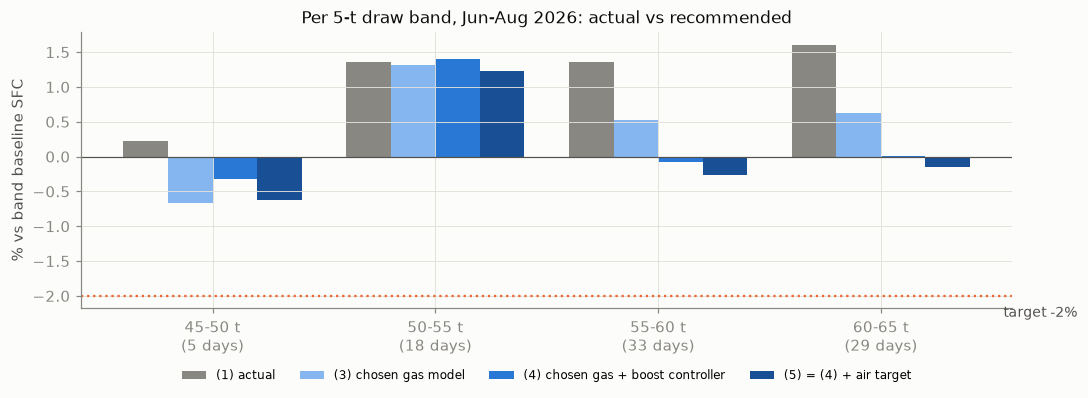

In [6]:
fig, ax = plt.subplots(figsize=(10, 3.8))
cols = ['(1) actual', '(3) chosen gas model', '(4) chosen gas + boost controller', '(5) = (4) + air target']
colr = [MUTED, '#86b6ef', BLUE, '#184f95']
x = np.arange(len(pct)); w = 0.2
for i, (c, cl) in enumerate(zip(cols, colr)):
    ax.bar(x + (i - 1.5) * w, pct[c], width=w, color=cl, label=c)
ax.axhline(-2, color=ORANGE, lw=1.5, ls=':'); ax.text(len(pct) - 0.45, -2.15, 'target -2%', color=INK2, fontsize=9, va='top')
ax.axhline(0, color=INK2, lw=0.8); ax.set_xticks(x); ax.set_xticklabels([f'{b}\n({n} days)' for b, n in zip(pct.index, bt.days)])
ax.set_ylabel('% vs band baseline SFC'); ax.set_title('Per 5-t draw band, Jun-Aug 2026: actual vs recommended')
ax.legend(loc='upper center', ncol=4, bbox_to_anchor=(0.5, -0.18), fontsize=8); plt.tight_layout(); plt.show()

**Reading section 2**
- **Against today's operation**, the full recommendation (5) saves about **1.3% SFC** (1.27%). The chosen gas model gives slightly less than the first version (0.70% vs 0.76%), but it is more accurate (T1) and holds its calibration on September (§2c). Its saving is the one we can defend.
- **Draw-adjusted (Model A)**, the furnace moves from **+1.14%** above the baseline to **−0.17%**.
- **Ageing-adjusted (Model B)**, actual operation is +0.56% and the recommendation is **−0.73%**. That is the honest operational improvement once furnace ageing is set aside.
- **Per band**, the 55–60 t and 60–65 t bands (most days) move just below their band baselines (−0.26% and −0.15%), but not yet to −2%. The 50–55 t band stays above its baseline.
- **The gap to −2% is about 1.8 points** (draw-adjusted). It needs the trial levers in `docs/05_final_approach_and_trial_plan.md`.

### 2b. All gas-model candidates from T1, on the client's two yardsticks
Gas only (actual boost), Jun–Aug 2026, walk-forward. This shows the final choice also holds up on the targets the client uses, not only on accuracy.

In [7]:
import lightgbm as lgb, warnings
warnings.simplefilter('ignore')
def cand(name, day):
    hist = u[u.index < day]; rec = hist[hist.index >= day - pd.Timedelta(days=45)]; x = u.loc[[day]]
    if name == 'QR rolling 45d (first version)':
        return rc.daily_gas_target(u, day, method='qr_rolling')
    if name == 'QR rolling 60d':
        return rc.daily_gas_target(u, day, method='qr_rolling', window=60)
    if name == 'QR expanding + ageing':
        return smf.quantreg('gas_g ~ draw_t + bb_g + mb_g + age_m', hist).fit(q=0.25, max_iter=5000).predict(x).iloc[0]
    if name == 'OLS expanding + ageing + optical + conformal (earlier choice)':
        return rc.daily_gas_target(u, day, method='ols_conformal_opt')
    if name == 'LightGBM expanding + ageing':
        X = ['draw_t', 'bb_g', 'mb_g', 'age_m']
        return lgb.LGBMRegressor(objective='quantile', alpha=0.25, n_estimators=200, learning_rate=0.05, num_leaves=7, min_child_samples=15, verbose=-1).fit(hist[X], hist.gas_g).predict(x[X])[0]
    if name == 'CHOSEN: OLS expanding + ageing + conformal':
        return rc.daily_gas_target(u, day)
NAMES = ['QR rolling 45d (first version)', 'QR rolling 60d', 'QR expanding + ageing', 'LightGBM expanding + ageing',
         'OLS expanding + ageing + optical + conformal (earlier choice)', 'CHOSEN: OLS expanding + ageing + conformal']
rows = []
for nm in NAMES:
    t = pd.Series({day: cand(nm, day) for day in TEST})
    Eg = t + te.bb_g + te.mb_g; sfc = Eg * 1e6 / te.draw_kg
    bp = 100 * (sfc.groupby(band, observed=True).mean() / band_base.reindex(sfc.groupby(band, observed=True).mean().index) - 1)
    rows.append({'candidate': nm, 'share of days below target': (te.gas_g <= t).mean(), 'MAE (Gcal/day)': (te.gas_g - t).abs().mean(),
                 'saving vs actual %': 100 * (1 - sfc.mean() / SFC['(1) actual'].mean()),
                 'draw-adjusted vs baseline % (A)': 100 * (Eg / mA.predict(te) - 1).mean(),
                 **{f'band {b} %': v for b, v in bp.items()}})
cands = pd.DataFrame(rows).set_index('candidate')
cands.round(2)

,share of days below target,MAE (Gcal/day),saving vs actual %,draw-adjusted vs baseline % (A),band 45-50 t %,band 50-55 t %,band 55-60 t %,band 60-65 t %
candidate,,,,,,,,
QR rolling 45d (first version),0.25,1.20,0.76,0.37,-0.24,1.00,0.45,0.68
QR rolling 60d,0.11,1.36,1.19,-0.06,-0.30,-0.21,0.29,0.36
QR expanding + ageing,0.15,1.07,0.82,0.31,-1.13,0.92,0.57,0.58
LightGBM expanding + ageing,0.16,1.17,0.85,0.26,0.15,1.05,0.63,0.07
OLS expanding + ageing + optical + conformal (earlier choice),0.20,1.01,0.68,0.45,-0.54,1.27,0.53,0.70
CHOSEN: OLS expanding + ageing + conformal,0.20,1.04,0.70,0.42,-0.67,1.31,0.53,0.63


In [8]:
cands.to_csv(dp.PROCESSED / 'T4_candidates_scorecard.csv'); score.to_csv(dp.PROCESSED / 'T4_scorecard.csv'); pct.to_csv(dp.PROCESSED / 'T4_band_pct.csv')

**Reading 2b**
- **QR rolling 60 d, QR expanding + ageing, LightGBM:** these look better on the yardsticks only because their targets are **too low**. Just 11–16% of days actually met them, against 25% intended. A recommender that promises savings the furnace rarely achieves would lose operator trust in the trial.
- **QR rolling 45 d (the first version):** also realistic (25%), and it shows a bit more saving (0.76% vs 0.70%). But its daily targets are about **15% less accurate** (error 1.20 vs 1.04 Gcal/day), its accuracy score over the two T1 test periods was clearly worse (0.386 vs 0.344), and on September it was the least accurate of the three (nb04 §8).
- **OLS + ageing + optical (the earlier choice):** almost identical on Jun–Aug (0.68% vs 0.70%), but it lost its calibration in September (41% of days below target) and is no longer used.
- **Chosen model:** an accurate target with realistic coverage in every period, including the unseen month. Its savings are the ones the trial can actually deliver and verify.

### 2c. Sep 2026 validation (unseen month)
The same walk-forward scorecard on September 2026, whose draw arrived with the corrected file. The barrier-boost controller is replayed on September's hours. September was used once, to decide that optical stays out of the gas model (nb04 §8); nothing else was tuned on it.

In [9]:
SEP = u[(u.index >= '2026-09-01') & (u.index <= '2026-09-30')].index
sim_s = rc.simulate_boost_controller(h.loc['2026-09-01':'2026-09-30 23:00'], step, FR.mb3_target, ki=0.1, bb_limits=FR.limits['bb_kwh_h'])
bbd_s = sim_s.bb_rec.groupby(sim_s.index.normalize()).mean() * 24
SEP = SEP[SEP.isin(bbd_s.dropna().index)]
ts_ = u.loc[SEP].copy()
ts_o = rc.walk_forward_gas_targets(u, SEP, method='qr_rolling'); ts_n = rc.walk_forward_gas_targets(u, SEP)
ts_nb = pd.Series({day: rc.daily_gas_target(u, day, {'bb_g': bbd_s[day] * 860 / 1e6}) for day in SEP})
air_s = pd.Series({day: rc.air_target(u, day) for day in SEP})
ES = pd.DataFrame({'(1) actual': ts_.E_g,
                   '(2) first gas version': ts_o + ts_.bb_g + ts_.mb_g,
                   '(3) chosen gas model': ts_n + ts_.bb_g + ts_.mb_g,
                   '(4) chosen gas + boost controller': ts_nb + bbd_s.reindex(SEP) * 860 / 1e6 + ts_.mb_g})
ES['(5) = (4) + air target'] = ES['(4) chosen gas + boost controller'] - ma.params.air_per_mcal * (ts_.air_per_mcal - air_s).clip(lower=0)
SFC_S = ES.mul(1e6).div(ts_.draw_kg, axis=0)
band_s = pd.cut(ts_.draw_t, bins, labels=labels, include_lowest=True)
print('Sep 2026: %d usable days | share of days below the chosen gas target: %.0f%% (25%% expected) | MB3 actual %.2f -> simulated %.2f' % (
      len(SEP), 100 * (ts_.gas_g <= ts_n).mean(), h.loc['2026-09'].mb3_temp.mean(), sim_s.mb3_sim.mean()))
score_s = pd.DataFrame({
    'SFC (kcal/kg)': SFC_S.mean(),
    'saving vs actual %': 100 * (1 - SFC_S.mean() / SFC_S['(1) actual'].mean()),
    'draw-adjusted vs baseline % (Model A)': 100 * (ES.div(mA.predict(ts_), axis=0) - 1).mean(),
    'ageing-adjusted vs baseline % (Model B)': 100 * (ES.div(mB.predict(ts_), axis=0) - 1).mean()})
score_s.to_csv(dp.PROCESSED / 'T4_scorecard_sep.csv')
display(score_s.round(2))
pct_s = 100 * (SFC_S.groupby(band_s, observed=True).mean().div(band_base.reindex(SFC_S.groupby(band_s, observed=True).mean().index), axis=0) - 1)
pct_s.insert(0, 'days', band_s.value_counts().reindex(pct_s.index))
print('% vs band baseline (target -2.0):'); pct_s.round(2)

Sep 2026: 27 usable days | share of days below the chosen gas target: 26% (25% expected) | MB3 actual 1319.67 -> simulated 1320.22


,SFC (kcal/kg),saving vs actual %,draw-adjusted vs baseline % (Model A),ageing-adjusted vs baseline % (Model B)
(1) actual,1610.40,0.00,1.68,0.52
(2) first gas version,1600.60,0.61,1.07,-0.08
(3) chosen gas model,1601.35,0.56,1.13,-0.03
(4) chosen gas + boost controller,1604.09,0.39,1.29,0.13
(5) = (4) + air target,1601.61,0.55,1.13,-0.03


% vs band baseline (target -2.0):


,days,(1) actual,(2) first gas version,(3) chosen gas model,(4) chosen gas + boost controller,(5) = (4) + air target
draw_t,,,,,,
45-50 t,1,-1.24,0.88,-1.55,-0.72,-1.12
50-55 t,7,2.17,0.85,0.96,1.56,1.42
55-60 t,12,1.49,0.96,0.91,0.84,0.72
60-65 t,7,0.98,0.53,1.08,1.10,0.91


**Reading 2c (Sep 2026)**
- **Gas target:** 26% of days below it (25% intended), so the target stays realistic on a month no model was tuned to. Gas alone saves **0.56%** SFC (Jun–Aug: 0.70%).
- **Barrier boost:** MB3 ran *below* its target in September (1,319.7 vs 1,320.25 °C), so the controller **adds** boost to warm the bottom. That costs energy (gas + boost 0.39%). This is correct: the controller holds MB3, not a boost level. In Jun–Aug MB3 was too hot and the same controller saved boost.
- **With the air trim:** **0.55%** SFC; draw-adjusted **+1.68% → +1.13%**; ageing-adjusted +0.52% → −0.03%.
- **Per band:** every band with more than one day improves, but none reaches −2%.
- **What this means:** the data-proven levers remove the inefficiency that is there. In a summer month with a hot bottom that is about 1.3%; in a month with a cold bottom it is about 0.5%. The −2% needs the trial levers on top (optical setpoint, MB3 target, draw).

## 3. Are the recommended values inside the historical limits?

In [10]:
rows = []
for day in TEST:
    qd = q.loc[str(day.date())]
    bbh = sim.loc[str(day.date()), 'bb_rec']
    for ts, r in qd.iterrows():
        if np.isnan(r.ncv):
            continue
        hr = ts.floor('h')
        inputs = dict(date=day, ncv=r.ncv, draw_t=te.loc[day, 'draw_t'], cullet_pct=te.loc[day, 'cullet_pct'],
                      optical_prev24h=te.loc[day, 'opt_f_prev'], bb_kwh_last_hour=float(bbh.get(hr - pd.Timedelta(hours=1), np.nan)) if (hr - pd.Timedelta(hours=1)) in bbh.index else float(h.bb_kwh.get(hr, 350)),
                      mb_kwh_last_hour=float(h.mb_kwh.get(hr, 300)), mb3_now=float(h.mb3_temp.get(hr, FR.mb3_target)))
        if any(pd.isna(v) for k, v in inputs.items() if k != 'date'):
            continue
        rec = FR.recommend(inputs)
        rows.append(dict(ts=ts, ng=rec.iloc[1, 2], ng_raw=rec.iloc[1, 1], air=rec.iloc[2, 2], afr=rec.iloc[3, 2], bb=rec.iloc[4, 2],
                         clipped=bool(rec['clipped?'].any()), clip_target=bool(rec['clipped?'].iloc[0]), clip_ng=bool(rec['clipped?'].iloc[1]),
                         clip_air=bool(rec['clipped?'].iloc[2]), clip_afr=bool(rec['clipped?'].iloc[3]), clip_bb=bool(rec['clipped?'].iloc[4])))
R = pd.DataFrame(rows).set_index('ts')
L = FR.limits
chk = pd.DataFrame({'recommended P1': [R.ng.quantile(.01), R.air.quantile(.01), R.afr.quantile(.01), R.bb.quantile(.01)],
                    'recommended P99': [R.ng.quantile(.99), R.air.quantile(.99), R.afr.quantile(.99), R.bb.quantile(.99)],
                    'historical P1': [L['ng_scm'][0], L['sec_air'][0], L['afr'][0], L['bb_kwh_h'][0]],
                    'historical P99': [L['ng_scm'][1], L['sec_air'][1], L['afr'][1], L['bb_kwh_h'][1]]},
                   index=['NG (per 15 min)', 'secondary air (per 15 min)', 'AFR', 'barrier boost (kWh/h)'])
print('15-min recommendations replayed: %d (models trained on all history; this section checks limits only, savings are in section 2)' % len(R))
print('clipped share by setpoint (%%): NG %.2f | secondary air %.2f | AFR %.2f | barrier boost %.2f' % tuple(100 * R[c].mean() for c in ['clip_ng', 'clip_air', 'clip_afr', 'clip_bb']))
print('(the daily gas target is an outcome, not a setpoint: it is only flagged when outside its daily history)')
chk.round(2)

15-min recommendations replayed: 8059 (models trained on all history; this section checks limits only, savings are in section 2)
clipped share by setpoint (%): NG 0.91 | secondary air 0.30 | AFR 0.30 | barrier boost 1.85
(the daily gas target is an outcome, not a setpoint: it is only flagged when outside its daily history)


,recommended P1,recommended P99,historical P1,historical P99
NG (per 15 min),76.00,96.18,73.86,96.34
secondary air (per 15 min),980.85,1087.51,920.51,1104.22
AFR,11.14,13.10,10.99,13.44
barrier boost (kWh/h),114.70,453.60,114.30,609.80


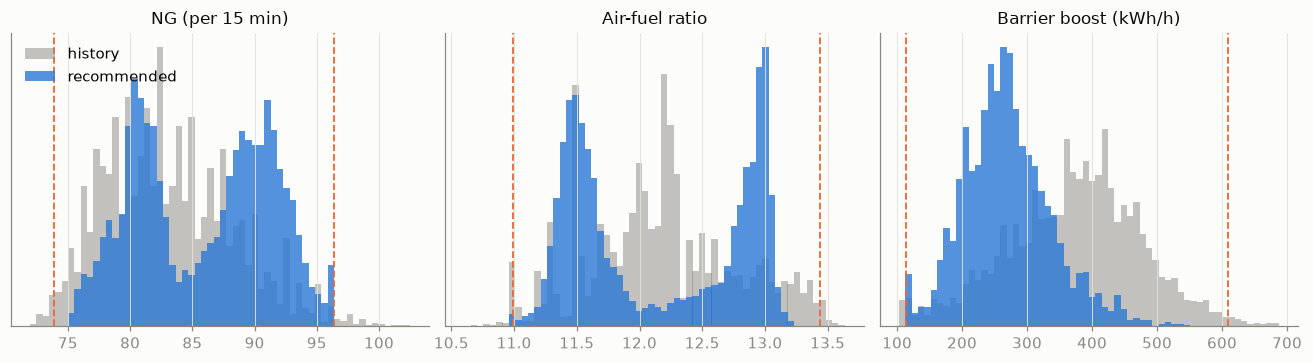

In [11]:
fig, ax = plt.subplots(1, 3, figsize=(12, 3.4))
for a_, col, hist, lim, ttl in [(ax[0], 'ng', q.ng_scm, L['ng_scm'], 'NG (per 15 min)'), (ax[1], 'afr', q.afr, L['afr'], 'Air-fuel ratio'),
                                (ax[2], 'bb', h.bb_kwh, L['bb_kwh_h'], 'Barrier boost (kWh/h)')]:
    rng = (hist.quantile(.001), hist.quantile(.999))
    a_.hist(hist.dropna(), bins=60, range=rng, color=MUTED, alpha=0.5, density=True, label='history')
    a_.hist(R[col], bins=60, range=rng, color=BLUE, alpha=0.8, density=True, label='recommended')
    for v in lim: a_.axvline(v, color=ORANGE, lw=1.2, ls='--')
    a_.set_title(ttl); a_.set_yticks([])
ax[0].legend(loc='upper left'); plt.tight_layout(); plt.show()

**Reading section 3.**
- Every **setpoint** (NG, secondary air, AFR, boost) is inside the historical P1–P99 limits (orange lines). Fewer than 2% of intervals touched a limit and were held there (mostly boost at its lower limit when MB3 was high).
- The *daily gas total* is an outcome, not a setpoint. On days with less boost and an aged furnace it can be slightly above the historical daily P99; actual operation also exceeded it on a few days (Jun, Aug and Sep 2026), so this is only flagged.
- If NG is at its upper limit, the boost controller doesn't lower the boost in that hour.

 The recommended NG range is *narrower* than history: steady heat with exact NCV compensation removes the extremes. The boost recommendations sit in the lower-middle of the historical range, because MB3 was running above its target in Jun–Aug.

## 4. Recommended ranges (look-up tables for the operators)
### 4a. NG setpoint by NCV and draw
Typical conditions: barrier boost 350 kWh/h, melter boost 300 kWh/h (optical is only a guard-rail, so it doesn't change the NG).

In [12]:
ncvs = list(range(8600, 10500, 200)); draws = [52, 55, 58, 61]
tab = pd.DataFrame(index=[f'NCV {v}' for v in ncvs])
air_tab = pd.DataFrame(index=tab.index)
for dr in draws:
    vals, afrs = [], []
    for v in ncvs:
        r = FR.recommend(dict(date='2026-10-05', ncv=v, draw_t=dr, cullet_pct=18, optical_prev24h=1574.5,
                              bb_kwh_last_hour=350, mb_kwh_last_hour=300, mb3_now=FR.mb3_target))
        vals.append(r.iloc[1, 2]); afrs.append(r.iloc[3, 2])
    tab[f'draw {dr} t'] = vals; air_tab[f'draw {dr} t'] = afrs
print('NG setpoint (workbook unit per 15 min); historical limits %.1f-%.1f' % L['ng_scm']); display(tab.round(1))
print('Air-fuel ratio (secondary air = AFR x NG); historical limits %.2f-%.2f' % L['afr']); air_tab.round(2)

NG setpoint (workbook unit per 15 min); historical limits 73.9-96.3


,draw 52 t,draw 55 t,draw 58 t,draw 61 t
NCV 8600,92.0,93.8,95.6,96.3
NCV 8800,89.9,91.6,93.4,95.2
NCV 9000,87.9,89.6,91.3,93.0
NCV 9200,86.0,87.7,89.3,91.0
NCV 9400,84.1,85.8,87.4,89.1
NCV 9600,82.4,84.0,85.6,87.2
NCV 9800,80.7,82.3,83.9,85.5
NCV 10000,79.1,80.6,82.2,83.7
NCV 10200,77.5,79.1,80.6,82.1
NCV 10400,76.1,77.5,79.0,80.5


Air-fuel ratio (secondary air = AFR x NG); historical limits 10.99-13.44


,draw 52 t,draw 55 t,draw 58 t,draw 61 t
NCV 8600,10.99,10.99,10.99,10.99
NCV 8800,11.16,11.16,11.16,11.16
NCV 9000,11.41,11.41,11.41,11.41
NCV 9200,11.66,11.66,11.66,11.66
NCV 9400,11.92,11.92,11.92,11.92
NCV 9600,12.17,12.17,12.17,12.17
NCV 9800,12.42,12.42,12.42,12.42
NCV 10000,12.68,12.68,12.68,12.68
NCV 10200,12.93,12.93,12.93,12.93
NCV 10400,13.18,13.18,13.18,13.18


### 4b. Barrier boost change for the next hour, by current MB3 (target 1320.25 °C)

In [13]:
mb3s = np.arange(1317.0, 1324.5, 1.0)
bt_tab = pd.DataFrame({'MB3 now (°C)': mb3s,
                       'change vs current boost (kWh/h)': [0.1 * (FR.mb3_target - m) / FR.mb3_gain for m in mb3s]})
bt_tab['if boost now = 350 kWh/h -> next hour'] = np.clip(350 + bt_tab['change vs current boost (kWh/h)'], *L['bb_kwh_h'])
bt_tab.round(1)

,MB3 now (°C),change vs current boost (kWh/h),if boost now = 350 kWh/h -> next hour
0,1317.0,16.8,366.8
1,1318.0,11.6,361.6
2,1319.0,6.4,356.4
3,1320.0,1.3,351.3
4,1321.0,-3.9,346.1
5,1322.0,-9.1,340.9
6,1323.0,-14.2,335.8
7,1324.0,-19.4,330.6


## 5. ✏️ Live recommendation: enter the current plant values here
Edit the values and re-run the cell. Every output is checked against the historical limits. Inputs outside history are flagged.

In [14]:
INPUTS = dict(
    date='2026-10-05',          # today
    ncv=9300,                   # latest NCV (kcal/SCM), valid range 8,500-10,500
    draw_t=58.0,                # expected draw today (t/day)
    cullet_pct=18,              # cullet % today
    optical_prev24h=1574.5,     # average of the optical readings typed in the last 24 h (°C)
    bb_kwh_last_hour=350,       # barrier boost in the last hour (kWh), from DB
    mb_kwh_last_hour=300,       # melter boost in the last hour (kWh), from DB
    mb3_now=1321.5,             # MB3 bottom temperature now (°C), from DCS
)
rec = FR.recommend(INPUTS)
display(rec.round(2))
print('Flags:', rec.attrs['flags'] if rec.attrs['flags'] else 'none (all inputs and setpoints inside history)')

,item,model value,recommended (within limits),unit,historical P1-P99,clipped?
0,Daily gas heat target (not a setpoint; flagged...,78.91,78.91,Gcal/day,72.54 - 80.90,False
1,"NG setpoint (per 15 min, workbook unit)",88.38,88.38,SCM/15 min,73.86 - 96.34,False
2,"Secondary air (per 15 min, workbook unit)",1041.92,1041.92,SCM/15 min,920.51 - 1104.22,False
3,Air-fuel ratio,11.79,11.79,-,10.99 - 13.44,False
4,"Barrier boost, next hour",343.53,343.53,kWh/h,114.30 - 609.80,False
5,"Barrier boost, next hour (per 15 min)",85.88,85.88,kWh/15 min,28.57 - 152.45,False


Flags: none (all inputs and setpoints inside history)


**How the operator uses it**
- **Every 20-min reversal cycle**, by minute 15: set the NG flow (row 2) and the secondary air / AFR (rows 3–4) using the latest NCV.
- **Every hour:** set the barrier boost (row 5). The gas recommendation then reads that boost from the DB on the next cycle.
- **If a row says "clipped"**, the model wanted to go outside history and the value was held at the limit. Report it to the process engineer.
- **Optical** is typed in as the last 24 h average. It doesn't change the gas recommendation; it is checked against its historical band and flagged if outside (then the shift engineer checks the crown before following the recommendation).

## 6. Back-test: what does history say for these input values?
Two steps:
1. **Replay the whole recommender over history (walk-forward)**, from 1 Dec 2025 to 29 Sep 2026. Each day only uses earlier days, exactly as it would have worked live: the gas target, the barrier-boost controller (replayed hour by hour) and the air trim. The result is saved to `data/processed/backtest_daily.parquet`.
2. **`backtest_inputs(INPUTS)`** picks the **similar days** in that replay: draw within ±1.5 t, daily NCV within ±150 kcal/SCM, cullet within ±1%. If fewer than 10 days match, the window is widened automatically and the output says so. For those days it shows:
   - the **actual average SFC** (what the furnace really did)
   - the **recommender's average SFC on the same days** (what it would have done)
   - both **draw-adjusted** and against the **5-t band baseline**
   - the **setpoints** operators used on those days (all, and the best 25%) next to today's recommendation

In [15]:
BT = rc.walk_forward_history(d, h, start='2025-12-01')
BT.to_parquet(dp.PROCESSED / 'backtest_daily.parquet')
mon = BT.groupby(BT.index.to_period('M')).agg(days=('sfc_actual', 'size'), draw_t=('draw_t', 'mean'), SFC_actual=('sfc_actual', 'mean'),
                                              SFC_recommender=('sfc_rec', 'mean'), draw_adj_actual_pct=('draw_adj_actual', 'mean'),
                                              draw_adj_recommender_pct=('draw_adj_rec', 'mean'))
mon['saving_pct'] = 100 * (1 - mon.SFC_recommender / mon.SFC_actual)
print('Replayed days: %d | average SFC actual %.1f -> recommender %.1f (saving %.2f%%) | draw-adjusted %+.2f%% -> %+.2f%%' % (
      len(BT), BT.sfc_actual.mean(), BT.sfc_rec.mean(), 100 * (1 - BT.sfc_rec.mean() / BT.sfc_actual.mean()),
      BT.draw_adj_actual.mean(), BT.draw_adj_rec.mean()))
mon.round(2)

Replayed days: 292 | average SFC actual 1583.4 -> recommender 1569.8 (saving 0.86%) | draw-adjusted +0.47% -> -0.40%


,days,draw_t,SFC_actual,SFC_recommender,draw_adj_actual_pct,draw_adj_recommender_pct,saving_pct
date,,,,,,,
2025-12,31,59.01,1556.53,1551.31,0.42,0.09,0.34
2026-01,31,58.11,1558.96,1546.09,-0.29,-1.10,0.83
2026-02,28,55.88,1597.04,1566.98,-0.26,-2.15,1.88
2026-03,29,57.11,1580.34,1574.49,0.06,-0.32,0.37
2026-04,30,57.82,1571.85,1565.38,-0.11,-0.53,0.41
2026-05,31,58.96,1552.58,1544.82,-0.03,-0.53,0.50
2026-06,30,56.17,1611.94,1590.87,0.37,-0.95,1.31
2026-07,25,55.32,1640.20,1625.43,1.21,0.25,0.90
2026-08,30,59.77,1569.50,1545.32,1.84,0.27,1.54


Inputs: {'ncv': 9300, 'draw_t': 58.0, 'cullet_pct': 18, 'optical_prev24h': 1574.5, 'bb_kwh_last_hour': 350, 'mb_kwh_last_hour': 300, 'mb3_now': 1321.5}
Similar days: draw 56.5-59.5 t, NCV 9150-9450 kcal/SCM, cullet 17.0-19.0%


,value
similar historical days,13
period covered,2025-12-01 to 2026-09-04
average draw (t/day) | NCV,58.3 | 9313
1. ACTUAL average SFC on those days (kcal/kg),"1,579.77"
"2. RECOMMENDER on the same days, walk-forward (kcal/kg)","1,560.75"
saving vs actual (%),1.20
days where the recommender was better (%),84.62
3. draw-adjusted vs baseline: actual (%),1.20
draw-adjusted vs baseline: recommender (%),-0.02
4. band 55-60 t: baseline SFC | -2% target,1566.7 | 1535.4


Setpoints: history vs recommended now


,history: similar days (actual),history: best 25% of similar days,recommended now
"NG (per 15 min, at a similar NCV)",86.21,85.12,88.38
secondary air (per 15 min),1026.02,1008.45,1041.92
air-fuel ratio,11.91,11.86,11.79
barrier boost (kWh/h),375.91,380.79,343.53
MB3 (°C; recommended = target),1320.84,1320.59,1320.25


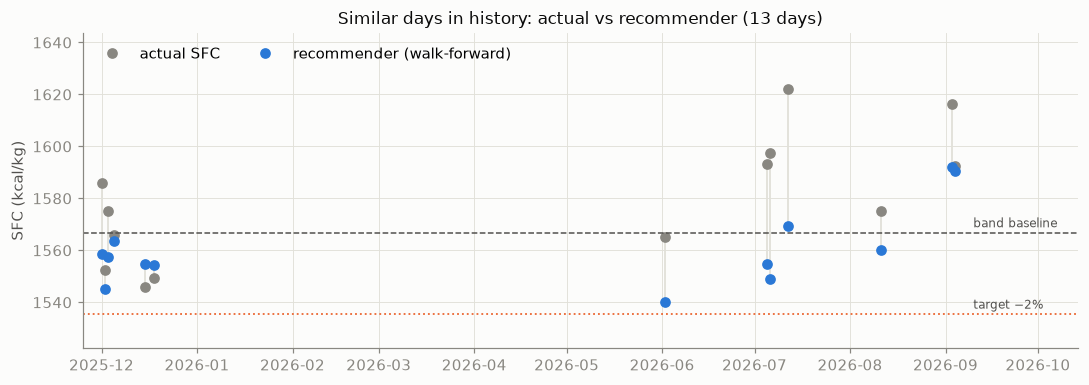

In [16]:
def backtest_inputs(inputs, draw_tol=1.5, ncv_tol=150, cullet_tol=1.0):
    """Similar days in history for these inputs: actual vs recommender SFC, yardsticks, setpoints."""
    pd.set_option('display.max_colwidth', 120)
    r = rc.history_backtest(FR, d, q, inputs, BT, draw_tol=draw_tol, ncv_tol=ncv_tol, cullet_tol=cullet_tol)
    print('Inputs:', {k: v for k, v in inputs.items() if k != 'date'})
    print('Similar days:', r['rule'])
    fmt = r['summary'].apply(lambda v: f'{v:,.2f}' if isinstance(v, (float, np.floating)) else v)
    display(fmt.to_frame('value'))
    print('Setpoints: history vs recommended now'); display(r['setpoints'].round(2))
    sim = r['similar_days']
    if len(sim):
        fig, ax = plt.subplots(figsize=(10, 3.6))
        ax.vlines(sim.index, sim.sfc_rec, sim.sfc_actual, color=GRID, lw=1.2)
        ax.plot(sim.index, sim.sfc_actual, 'o', color=MUTED, ms=6, label='actual SFC')
        ax.plot(sim.index, sim.sfc_rec, 'o', color=BLUE, ms=6, label='recommender (walk-forward)')
        ax.axhline(r['band_baseline'], color=INK2, lw=1, ls='--'); ax.axhline(r['band_baseline'] * 0.98, color=ORANGE, lw=1.2, ls=':')
        x_end = sim.index.max() + pd.Timedelta(days=6)
        ax.text(x_end, r['band_baseline'] + 1, 'band baseline', color=INK2, fontsize=8, va='bottom')
        ax.text(x_end, r['band_baseline'] * 0.98 + 1, 'target −2%', color=INK2, fontsize=8, va='bottom')
        lo = min(r['band_baseline'] * 0.98, sim.sfc_rec.min(), sim.sfc_actual.min()); hi = max(sim.sfc_rec.max(), sim.sfc_actual.max(), r['band_baseline'])
        ax.set_ylim(lo - 0.15 * (hi - lo), hi + 0.25 * (hi - lo))
        ax.set_xlim(sim.index.min() - pd.Timedelta(days=6), sim.index.max() + pd.Timedelta(days=40))
        ax.set_ylabel('SFC (kcal/kg)'); ax.set_title('Similar days in history: actual vs recommender (%d days)' % len(sim))
        ax.legend(loc='upper left', ncol=2); plt.tight_layout(); plt.show()
    return r

res = backtest_inputs(INPUTS)       # INPUTS from section 5; edit there and re-run both cells

**How to read the back-test**
- **Line 1 vs line 2** is the like-for-like answer: on days that looked like your inputs, this is what the furnace actually used and what it would have used with the recommendations (walk-forward). Both are on the same days, so draw, NCV and cullet are the same.
- **Line 3** removes the draw effect (Model A, the client's draw-adjusted yardstick); **line 4** compares with the 5-t band baseline. The target is −2% on either.
- **Line 5 (today)** is the SFC expected *today* if the recommendation is followed all day. It includes today's furnace age (the gas model adds about 0.35 Gcal/day per month of ageing), so it is usually **higher** than older similar days. That is ageing, not a worse recommendation; the saving is line 1 vs line 2.
- **Setpoints table:** what operators actually set on similar days, what the best 25% of those days used, and what is recommended now. Today's NG can be *higher* than history for two reasons: the furnace is older (ageing), and the recommended barrier boost is lower (each Gcal of boost removed is replaced by only ~0.77 Gcal of gas, so total energy still falls). The recommended NG is for *your* NCV, while history averages a ±150 window.
- **Whole-history replay (table above):** the recommender beats actual operation in every month from Dec 2025 to Sep 2026, by 0.3% to 1.9%.
- To widen or narrow the search, call e.g. `backtest_inputs(INPUTS, draw_tol=2, ncv_tol=250)`.